---
# STEP 7 FPI 구간별 텍스트 분석

## 분석 개요

STEP 6에서 확정된 FPI 구간(NP/LP/HP)별로 독립 브랜드 리뷰 텍스트를 분석하여
경쟁 압력 수준에 따라 소비자가 어떤 언어로 반응하는지 탐색한다.

| 단계 | 내용 |
|---|---|
| STEP 7-1 | 데이터 준비 (리뷰 + FPI 구간 조인) |
| STEP 7-2 | 텍스트 전처리 |
| STEP 7-3 | 구간별 TF-IDF 핵심 키워드 추출 |
| STEP 7-4 | 구간 간 TF-IDF 차이로 구간별 고유 단어 추출|
| STEP 7-5 | 시각화 (워드클라우드, 바차트) |

**입력 데이터**
- `review_target.csv`: 리뷰 텍스트 929,606개
- `biz_indie_with_groups.csv`: 독립 브랜드 FPI 구간 정보

**분석 단위**: 리뷰 단위 (브랜드 단위보다 텍스트 볼륨 풍부)

## 공통 라이브러리 및 설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import warnings
warnings.filterwarnings('ignore')

fm._load_fontmanager(try_read_cache=False)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

nltk.download('stopwords', quiet=True)

PATH_to_data = "../results"
PATH_to_save = "../results"

print("라이브러리 로드 완료")

라이브러리 로드 완료


---
## STEP 7-1. 데이터 준비

리뷰 데이터에 FPI 구간 정보를 조인한다.
영업 중인 독립 브랜드(is_open=1)의 리뷰만 사용한다.

In [3]:
# 데이터 로드
review = pd.read_csv(f"{PATH_to_data}/review_target.csv")
indie_groups = pd.read_csv(f"{PATH_to_data}/biz_indie_with_groups.csv")

# 영업 중인 독립 브랜드만 필터링 (STEP 6과 동일 기준)
indie_groups = indie_groups[indie_groups['is_open'] == 1].copy()

print(f"독립 브랜드: {len(indie_groups):,}개")
print(f"전체 리뷰: {len(review):,}개")

# 리뷰에 FPI 구간 조인
review_indie = review.merge(
    indie_groups[['business_id', 'fpi_group', 'fpi_300m']],
    on='business_id', how='inner'
)

print(f"\n조인 후 리뷰 수: {len(review_indie):,}개")
print(f"\nFPI 구간별 리뷰 수:")
print(review_indie['fpi_group'].value_counts())

독립 브랜드: 3,017개
전체 리뷰: 929,606개

조인 후 리뷰 수: 751,890개

FPI 구간별 리뷰 수:
fpi_group
HP    342861
LP    300586
NP    108443
Name: count, dtype: int64


---
## STEP 7-2. 텍스트 전처리

STEP 3과 동일한 전처리 방식을 적용한다.
- 소문자화, 숫자/구두점 제거
- 불용어 제거 (NLTK + 커스텀)
- 어간 추출 (Porter Stemmer)

In [3]:
## 저장된 전처리 결과 로드해서 사용

#  stop_words = set(stopwords.words('english')) | {"does", "not", "thing"}

# MANUAL_STOPWORDS = {
#     'al', 'also', 'alway', 'anoth', 'area', 'around', 'ask',
#     'back', 'bite', 'box',
#     'come', 'could', 'came',
#     'dont', 'day', 'de', 'didnt',
#     'even', 'ever', 'el',
#     'get', 'give', 'got',
#     'im', 'ive',
#     'let', 'la', 'last',
#     'make', 'made', 'mayb',
#     'name', 'one', 'round',
#     'someth', 'still', 'seem', 'sinc', 'sub', 'said',
#     'told', 'that', 'think', 'two', 'though', 'thought', 'took',
#     'us', 'want', 'way', 'went', 'would', 'wasnt',
#     'your', 'year', 'restaurant', 'place', 'food', 'get',
#     'go', 'came', 'got', 'time', 'back', 'order', 'ordered',
# }

# stemmer = PorterStemmer()

# def preprocess(text):
#     if pd.isna(text):
#         return ''
#     text = text.lower()
#     text = re.sub(r'\d+', '', text)
#     text = re.sub(r'[^\w\s]', '', text)
#     tokens = text.split()
#     tokens = [w for w in tokens if w not in stop_words]
#     tokens = [stemmer.stem(w) for w in tokens]
#     tokens = [w for w in tokens if w not in MANUAL_STOPWORDS and len(w) > 2]
#     return ' '.join(tokens)

# print("전처리 함수 정의 완료")
# print("전처리 시작 (시간 소요)...")

# review_indie['text_clean'] = review_indie['text'].apply(preprocess)

# print(f"전처리 완료: {len(review_indie):,}개 리뷰")
# print(f"\n샘플 확인:")
# print(review_indie[['text', 'text_clean']].head(3))

In [14]:
# 전처리 완료 후 저장
review_indie.to_csv(f"{PATH_to_data}/review_indie_cleaned.csv", index=False, na_rep='')
print("저장 완료")

저장 완료


In [15]:
#저장된 전처리 결과 로드
review_indie = pd.read_csv(f"{PATH_to_data}/review_indie_cleaned.csv")
indie_groups = pd.read_csv(f"{PATH_to_data}/biz_indie_with_groups.csv")
indie_groups = indie_groups[indie_groups['is_open'] == 1].copy()
print(f"로드 완료: {len(review_indie):,}개")

로드 완료: 751,890개


---
## STEP 7-3. 구간별 TF-IDF 핵심 키워드 확인 (탐색적)

FPI 구간별로 리뷰를 합쳐서 하나의 문서로 만들고 TF-IDF를 계산하여 각 구간의 핵심 키워드를 추출한다.

> **해석 주의**: 3개 구간을 각각 하나의 문서로 처리하면 문서 수가 3개에 불과하여
> IDF 효과가 거의 작동하지 않는다. 결과적으로 good, great, like 등
> 모든 구간에서 공통으로 자주 등장하는 단어만 상위에 올라온다.
> 이 분석은 **"전체적으로 어떤 단어가 많이 쓰이는가"를 탐색하는 수준**으로만 활용하며,
> 구간 간 차별화 키워드 분석은 STEP 7-4에서 수행한다.

In [5]:
# 구간별 리뷰 텍스트 합치기
group_texts = {}
for group in ['NP', 'LP', 'HP']:
    texts = review_indie[review_indie['fpi_group'] == group]['text_clean']
    group_texts[group] = ' '.join(texts.dropna().tolist())
    print(f"{group}: {len(texts):,}개 리뷰")

# TF-IDF 계산 (구간을 문서로)
corpus = [group_texts['NP'], group_texts['LP'], group_texts['HP']]

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=1,
    max_df=1.0,
    ngram_range=(1, 1)
)
tfidf_matrix = vectorizer.fit_transform(corpus)
terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=['NP', 'LP', 'HP'],
    columns=terms
)

print(f"\nTF-IDF 행렬: {tfidf_df.shape}")
print("(3개 구간 × 단어 수)")

NP: 108,443개 리뷰
LP: 300,586개 리뷰
HP: 342,861개 리뷰

TF-IDF 행렬: (3, 5000)
(3개 구간 × 단어 수)


In [6]:
# 구간별 상위 키워드 출력
TOP_N = 20

print("=" * 60)
for group in ['NP', 'LP', 'HP']:
    top_words = tfidf_df.loc[group].nlargest(TOP_N)
    print(f"\n[{group}] 상위 {TOP_N}개 키워드:")
    print(top_words.round(4).to_string())
    print()


[NP] 상위 20개 키워드:
good       0.3418
great      0.2363
like       0.2261
servic     0.2143
tri        0.1723
realli     0.1432
restaur    0.1365
vega       0.1339
love       0.1335
best       0.1200
eat        0.1118
wait       0.1096
delici     0.1030
price      0.1026
tast       0.1009
chicken    0.1003
nice       0.0998
well       0.0960
menu       0.0958
fri        0.0920


[LP] 상위 20개 키워드:
good       0.3397
great      0.2376
like       0.2246
servic     0.2218
tri        0.1625
restaur    0.1485
realli     0.1430
vega       0.1400
love       0.1263
eat        0.1179
best       0.1131
wait       0.1067
price      0.1028
delici     0.1017
tast       0.1015
nice       0.0997
menu       0.0982
chicken    0.0982
well       0.0974
tabl       0.0908


[HP] 상위 20개 키워드:
good       0.3397
great      0.2410
like       0.2204
servic     0.2203
tri        0.1561
vega       0.1498
realli     0.1442
restaur    0.1388
love       0.1214
eat        0.1130
chicken    0.1104
best       0.1066
wait    

---
## STEP 7-4. 구간별 고유 키워드 추출 (TF-IDF 차이 방식)

각 구간에서 다른 구간 대비 고유하게 나타나는 키워드를 추출한다.

초기에는 log-odds 방식을 시도하였으나, 특정 식당에만 등장하는 고유명사(브랜드명, 지명)가
상위에 올라오는 문제가 발생하였다. 이를 해결하기 위해 **구간 간 TF-IDF 차이 방식**으로 변경하였다.
500회 이상 등장한 알파벳 단어만 유효 단어로 사용하여 고유명사를 필터링하였다.

In [5]:
# word_freq 계산
all_text = ' '.join(review_indie['text_clean'].dropna()).split()
word_freq = pd.Series(all_text).value_counts()

MIN_COUNT = 500
valid_words = set(
    word for word, cnt in word_freq.items()
    if cnt >= MIN_COUNT
    and word.isalpha()
    and len(word) >= 3
)

print(f"전체 단어 수: {len(word_freq):,}개")
print(f"500회 이상 + 알파벳만 단어 수: {len(valid_words):,}개")

전체 단어 수: 298,603개
500회 이상 + 알파벳만 단어 수: 4,236개


In [6]:
# 구간별 리뷰 텍스트 합치기
group_texts = {}
for group in ['NP', 'LP', 'HP']:
    texts = review_indie[review_indie['fpi_group'] == group]['text_clean']
    group_texts[group] = ' '.join(texts.dropna().tolist())

corpus = [group_texts['NP'], group_texts['LP'], group_texts['HP']]
vectorizer = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_matrix = vectorizer.fit_transform(corpus)
terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=['NP', 'LP', 'HP'],
    columns=terms
)

# TF-IDF 차이 기반 고유 키워드
tfidf_diff_results = {}
for group, others in [('NP', ['LP', 'HP']),
                       ('LP', ['NP', 'HP']),
                       ('HP', ['NP', 'LP'])]:
    target_score = tfidf_df.loc[group]
    other_score  = tfidf_df.loc[others].mean()
    diff = (target_score - other_score).sort_values(ascending=False)
    diff = diff[diff.index.isin(valid_words)]
    tfidf_diff_results[group] = diff

print("TF-IDF 차이 계산 완료")
for group in ['NP', 'LP', 'HP']:
    print(f"\n[{group}] 상위 5개: {tfidf_diff_results[group].head(5).index.tolist()}")

TF-IDF 차이 계산 완료

[NP] 상위 5개: ['thai', 'coffe', 'pho', 'buffet', 'cake']

[LP] 상위 5개: ['pizza', 'steak', 'sushi', 'ramen', 'restaur']

[HP] 상위 5개: ['burger', 'drink', 'chees', 'sandwich', 'vega']


In [7]:
# 구간별 TF-IDF 차이로 고유 키워드 추출
# HP에서 높고 NP에서 낮은 단어 = HP 고유 키워드
for group, others in [('NP', ['LP', 'HP']),
                       ('LP', ['NP', 'HP']),
                       ('HP', ['NP', 'LP'])]:
    
    target_score = tfidf_df.loc[group]
    other_score  = tfidf_df.loc[others].mean()
    
    # 차이값 계산
    diff = (target_score - other_score).sort_values(ascending=False)
    
    # valid_words 필터 적용
    diff = diff[diff.index.isin(valid_words)]
    
    print(f"\n[{group}] 고유 키워드 상위 20개 (TF-IDF 차이):")
    print(diff.head(20).round(4).to_string())


[NP] 고유 키워드 상위 20개 (TF-IDF 차이):
thai        0.0399
coffe       0.0352
pho         0.0338
buffet      0.0317
cake        0.0206
wynn        0.0186
noodl       0.0171
bellagio    0.0147
sandwich    0.0136
tri         0.0130
rib         0.0127
cafe        0.0120
rice        0.0114
prime       0.0113
soup        0.0107
curri       0.0106
best        0.0101
pad         0.0101
bagel       0.0101
sum         0.0099

[LP] 고유 키워드 상위 20개 (TF-IDF 차이):
pizza       0.0228
steak       0.0205
sushi       0.0165
ramen       0.0137
restaur     0.0109
korean      0.0078
dish        0.0078
roll        0.0073
donut       0.0071
cook        0.0068
oyster      0.0066
rice        0.0065
fountain    0.0064
japanes     0.0063
server      0.0060
downtown    0.0057
slice       0.0056
sauc        0.0056
eat         0.0055
pan         0.0055

[HP] 고유 키워드 상위 20개 (TF-IDF 차이):
burger      0.0431
drink       0.0184
chees       0.0162
sandwich    0.0147
vega        0.0129
bread       0.0129
fri         0.0127
lobster 

---
## STEP 7-5. 시각화


### 구간 간 TF-IDF 차이 시각화

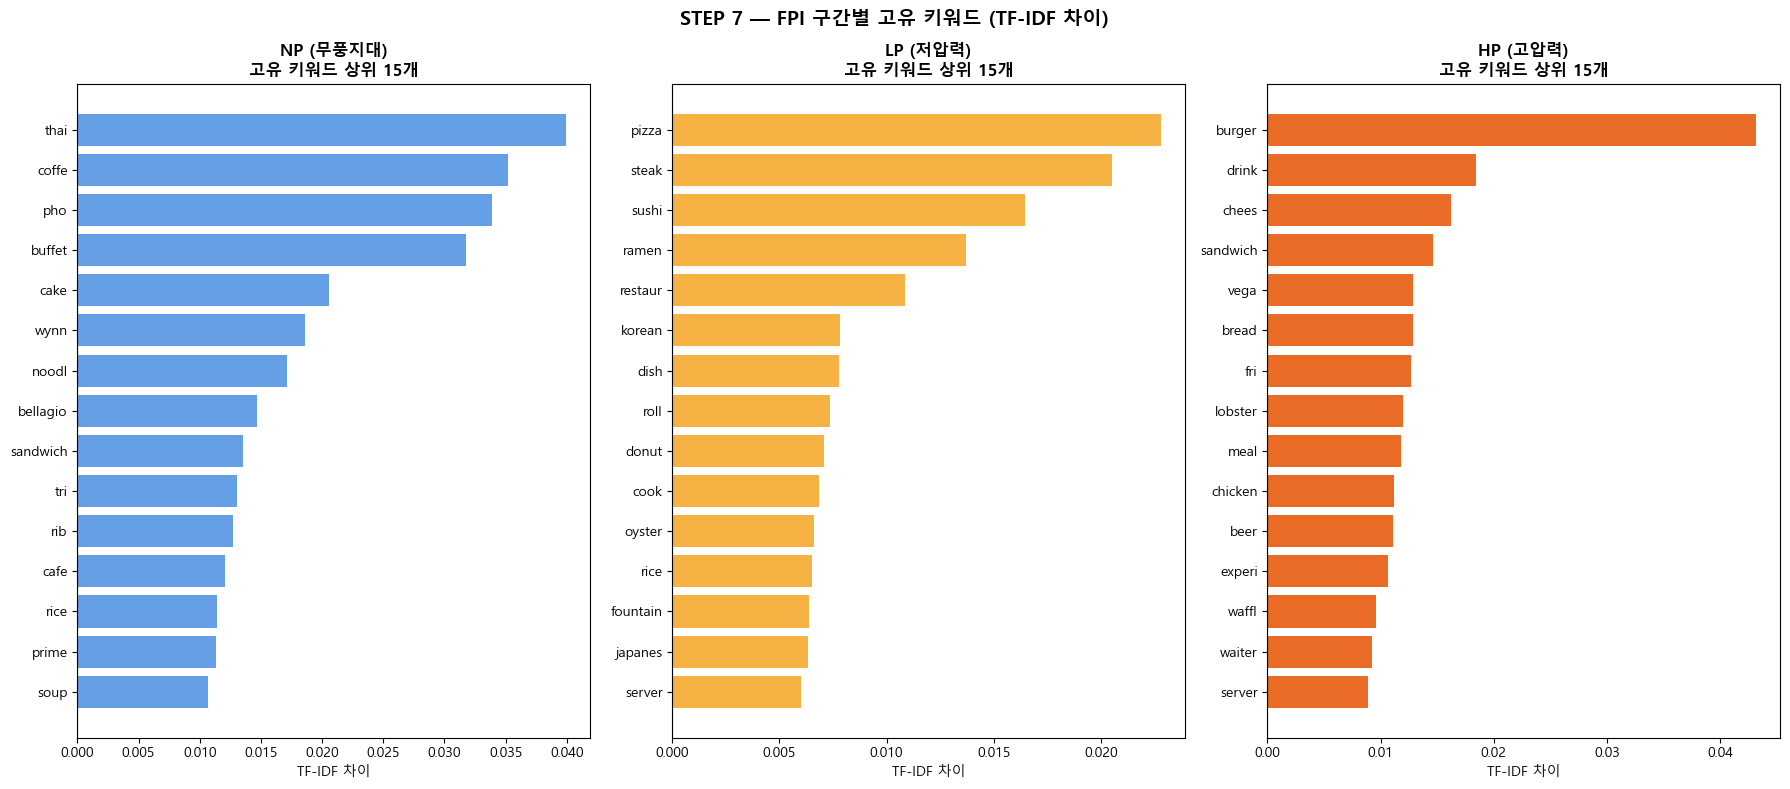

저장 완료: step7_tfidf_diff.png


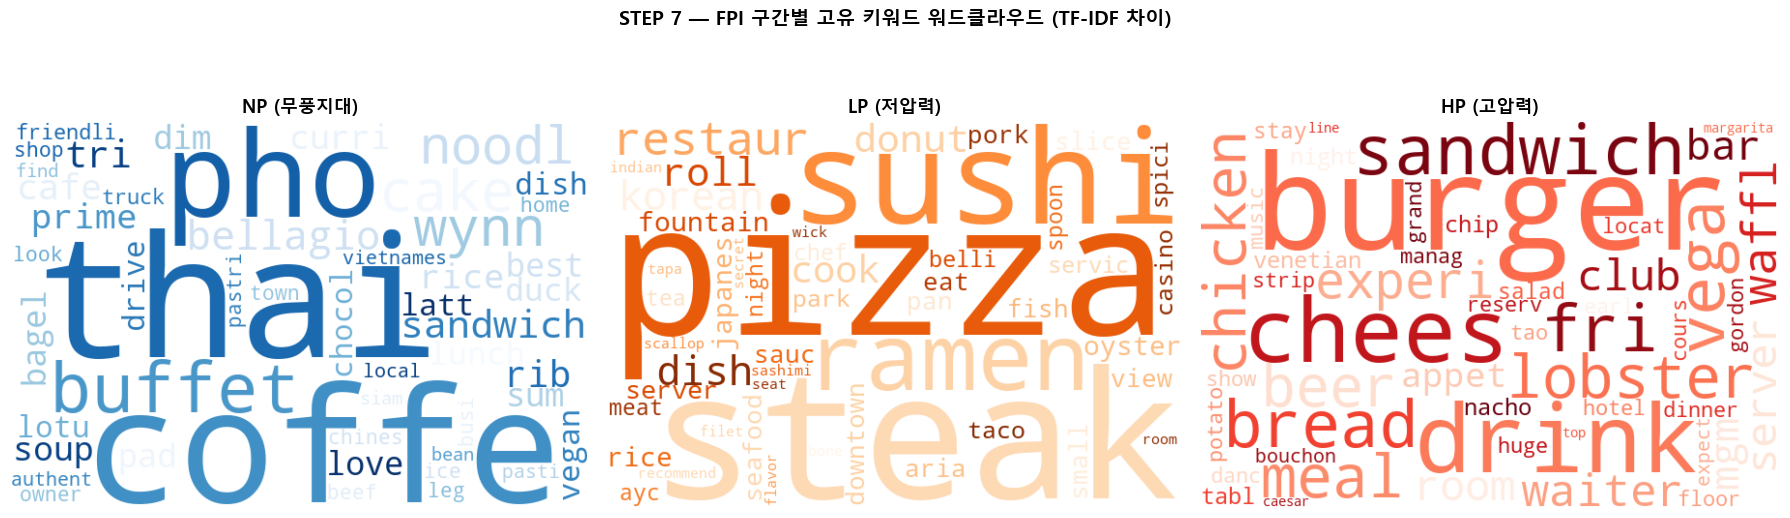

저장 완료: step7_tfidf_wordcloud.png


In [9]:
# TF-IDF 차이 기반 고유 키워드 저장
tfidf_diff_results = {}
for group, others in [('NP', ['LP', 'HP']),
                       ('LP', ['NP', 'HP']),
                       ('HP', ['NP', 'LP'])]:
    target_score = tfidf_df.loc[group]
    other_score  = tfidf_df.loc[others].mean()
    diff = (target_score - other_score).sort_values(ascending=False)
    diff = diff[diff.index.isin(valid_words)]
    tfidf_diff_results[group] = diff

# 바차트
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('STEP 7 — FPI 구간별 고유 키워드 (TF-IDF 차이)',
             fontsize=14, fontweight='bold')

bar_colors = {'NP': '#4a90e2', 'LP': '#f5a623', 'HP': '#e65100'}
titles = {'NP': 'NP (무풍지대)', 'LP': 'LP (저압력)', 'HP': 'HP (고압력)'}

for ax, group in zip(axes, ['NP', 'LP', 'HP']):
    top = tfidf_diff_results[group].head(15)
    ax.barh(top.index[::-1], top.values[::-1],
            color=bar_colors[group], alpha=0.85)
    ax.set_title(f'{titles[group]}\n고유 키워드 상위 15개',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('TF-IDF 차이')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step7_tfidf_diff.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step7_tfidf_diff.png")

# 워드클라우드
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('STEP 7 — FPI 구간별 고유 키워드 워드클라우드 (TF-IDF 차이)',
             fontsize=14, fontweight='bold')

wc_colors = {'NP': 'Blues', 'LP': 'Oranges', 'HP': 'Reds'}

for ax, group in zip(axes, ['NP', 'LP', 'HP']):
    top = tfidf_diff_results[group].head(50)
    freq_dict = {word: score for word, score in top.items() if score > 0}
    if freq_dict:
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=wc_colors[group],
            max_words=50
        ).generate_from_frequencies(freq_dict)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(titles[group], fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step7_tfidf_wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step7_tfidf_wordcloud.png")

---
## STEP 7-6. PCA Biplot — 구간별 언어 패턴 시각화

TF-IDF 고유 키워드 분석(7-4)에서 도출한 구간별 차별화 키워드를
PCA Biplot으로 시각화하여 언어 패턴 차이를 공간적으로 확인한다.

> **분석 한계**: 브랜드 단위 TF-IDF 기반 PCA에서 PC1, PC2 누적 설명력이 11.0%에 불과하여
> 구간 간 언어 패턴 차이를 2차원으로 명확히 표현하는 데 한계가 있다.
> 이는 Restaurants 카테고리 내 업종 다양성(피자집 vs 스시집 vs 버거집)이
> FPI 구간 차이보다 더 큰 분산을 설명하기 때문이다.
> **보조 시각화로만 활용하며**, 핵심 결과는 7-4 TF-IDF 차이 분석을 기준으로 한다.

**분석 설계**
- 각 점: 독립 브랜드 1개 (색깔 = FPI 구간)
- 화살표: 구간별 고유 키워드 (TF-IDF 차이 분석에서 도출)
  - NP 방향: thai, pho, coffee, buffet, noodle
  - LP 방향: pizza, steak, sushi, ramen, korean
  - HP 방향: burger, drink, cheese, waiter, server
  
**분석흐름**
- 7-6-1. 브랜드별 TF-IDF 계산 (min_df/max_df 필터)
- 7-6-2. PCA 수행 (브랜드 × 단어 → 2D)
- 7-6-3. Biplot 시각화
        - 점: 브랜드 (색깔 = NP/LP/HP)
        - 화살표: 구간별 고유 키워드만 선택
                  (thai,pho → NP방향 / pizza,sushi → LP방향 / burger,waiter → HP방향)
                  
**TF-IDF 파라미터**
- min_df=0.05: 전체 브랜드의 5% 미만 단어 제거 (고유명사, 희귀어 제거)
- max_df=0.90: 전체 브랜드의 90% 초과 단어 제거 (good, great 등 범용어 제거)

### 7-6-1. 브랜드별 TF-IDF 계산

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 브랜드별 리뷰 텍스트 합치기 (NaN 처리 추가)
brand_texts = review_indie.groupby('business_id').agg(
    text_clean=('text_clean', lambda x: ' '.join(x.dropna().astype(str))),
    fpi_group=('fpi_group', 'first')
).reset_index()

print(f"브랜드 수: {len(brand_texts):,}개")
print(f"\nFPI 구간 분포:")
print(brand_texts['fpi_group'].value_counts())

브랜드 수: 3,017개

FPI 구간 분포:
fpi_group
HP    1220
LP    1217
NP     580
Name: count, dtype: int64


In [17]:
# 브랜드별 TF-IDF 계산
vectorizer_pca = TfidfVectorizer(
    min_df=0.05,
    max_df=0.90,
    max_features=3000
)

tfidf_brand = vectorizer_pca.fit_transform(brand_texts['text_clean'])
terms_pca = vectorizer_pca.get_feature_names_out()

print(f"TF-IDF 행렬: {tfidf_brand.shape}")
print(f"  ({len(brand_texts):,}개 브랜드 × {len(terms_pca)}개 단어)")
print(f"\n단어 샘플 (상위 30개):")
print(terms_pca[:30])

TF-IDF 행렬: (3017, 3000)
  (3,017개 브랜드 × 3000개 단어)

단어 샘플 (상위 30개):
['abl' 'absolut' 'abund' 'accent' 'accept' 'access' 'accid' 'accident'
 'accommod' 'accompani' 'accord' 'account' 'accur' 'acid' 'acknowledg'
 'across' 'act' 'action' 'activ' 'actual' 'add' 'addict' 'addit' 'address'
 'adequ' 'adjust' 'admit' 'ador' 'adult' 'advanc']


### 7-6-2. PCA 수행

In [18]:
# PCA 수행
pca_brand = PCA(n_components=2, random_state=42)
scores_brand = pca_brand.fit_transform(tfidf_brand.toarray())
loadings_brand = pca_brand.components_.T

print(f"PC1 설명력: {pca_brand.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 설명력: {pca_brand.explained_variance_ratio_[1]*100:.1f}%")
print(f"누적 설명력: {sum(pca_brand.explained_variance_ratio_)*100:.1f}%")

# loading DataFrame
loading_brand_df = pd.DataFrame(
    loadings_brand,
    index=terms_pca,
    columns=['PC1', 'PC2']
)
loading_brand_df['magnitude'] = np.sqrt(
    loading_brand_df['PC1']**2 + loading_brand_df['PC2']**2
)

PC1 설명력: 6.3%
PC2 설명력: 4.7%
누적 설명력: 11.0%


### 7-6-3. PCA Biplot 시각화

구간별 고유 키워드(TF-IDF 차이 분석 결과)를 화살표로 표시한다.
각 구간의 대표 키워드가 해당 구간 브랜드들이 모인 방향으로 향하면
분석 결과가 공간적으로 검증된다.

In [19]:
# 구간별 고유 키워드 (STEP 7-4 결과)
highlight_words = {
    'NP': ['thai', 'pho', 'coffe', 'buffet', 'noodl', 'cake', 'soup', 'curri'],
    'LP': ['pizza', 'steak', 'sushi', 'ramen', 'korean', 'roll', 'oyster'],
    'HP': ['burger', 'drink', 'chees', 'waiter', 'server', 'beer', 'sandwich']
}

# 실제 TF-IDF 단어 목록에 있는 것만 필터링
highlight_words_valid = {}
for group, words in highlight_words.items():
    valid = [w for w in words if w in terms_pca]
    highlight_words_valid[group] = valid
    print(f"{group} 키워드 ({len(valid)}개): {valid}")

NP 키워드 (8개): ['thai', 'pho', 'coffe', 'buffet', 'noodl', 'cake', 'soup', 'curri']
LP 키워드 (7개): ['pizza', 'steak', 'sushi', 'ramen', 'korean', 'roll', 'oyster']
HP 키워드 (7개): ['burger', 'drink', 'chees', 'waiter', 'server', 'beer', 'sandwich']


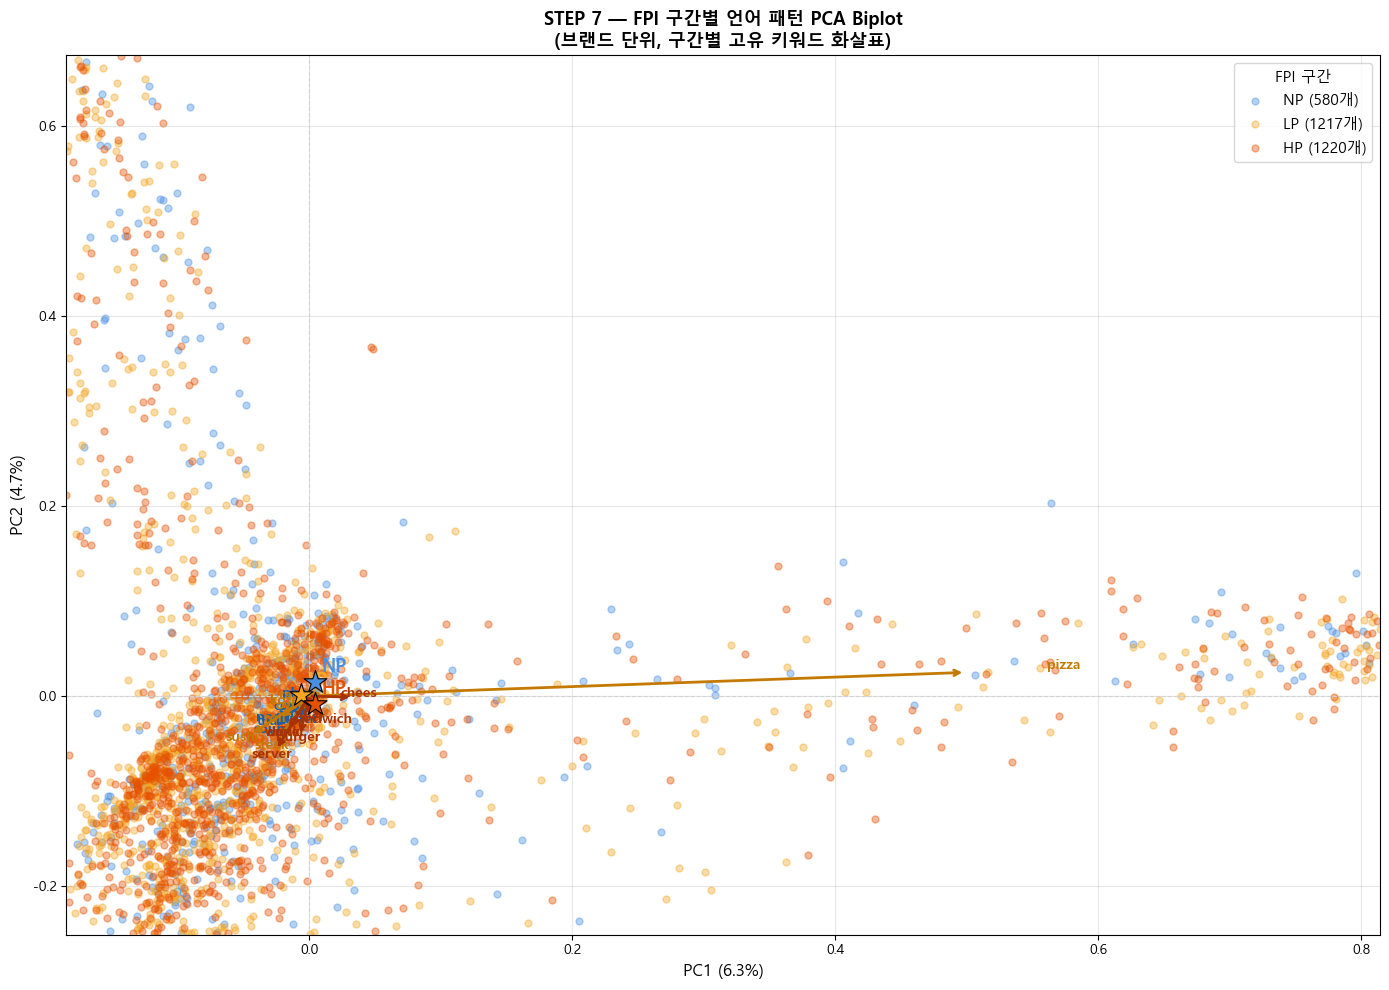

In [25]:
fig, ax = plt.subplots(figsize=(14, 10))

group_colors = {'NP': '#4a90e2', 'LP': '#f5a623', 'HP': '#e65100'}

# outlier 제거 (95% 범위만 표시)
x_min, x_max = np.percentile(scores_brand[:, 0], [2, 98])
y_min, y_max = np.percentile(scores_brand[:, 1], [2, 98])

for group in ['NP', 'LP', 'HP']:
    mask = brand_texts['fpi_group'] == group
    x = scores_brand[mask, 0]
    y = scores_brand[mask, 1]
    # 범위 내 점만 표시
    in_range = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
    ax.scatter(x[in_range], y[in_range],
               c=group_colors[group], alpha=0.4, s=25,
               label=f'{group} ({mask.sum()}개)')

# 구간 중심점
for group in ['NP', 'LP', 'HP']:
    mask = brand_texts['fpi_group'] == group
    cx = scores_brand[mask, 0].mean()
    cy = scores_brand[mask, 1].mean()
    ax.scatter(cx, cy, c=group_colors[group],
               s=300, marker='*', zorder=6,
               edgecolors='black', linewidth=0.8)
    ax.annotate(f'{group}',
                xy=(cx, cy), xytext=(cx+0.005, cy+0.01),
                fontsize=13, fontweight='bold', color=group_colors[group])

# 화살표 스케일을 축 범위에 맞게 조정
axis_range = max(x_max - x_min, y_max - y_min)
arrow_scale = axis_range * 0.5 / loading_brand_df['magnitude'].max()

arrow_colors = {'NP': '#1a5fa8', 'LP': '#c47a00', 'HP': '#a83200'}

for group, words in highlight_words_valid.items():
    for word in words:
        if word not in loading_brand_df.index:
            continue
        row = loading_brand_df.loc[word]
        ax.annotate(
            '',
            xy=(row['PC1'] * arrow_scale, row['PC2'] * arrow_scale),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color=arrow_colors[group], lw=2.0)
        )
        ax.text(
            row['PC1'] * arrow_scale * 1.15,
            row['PC2'] * arrow_scale * 1.15,
            word, fontsize=10, color=arrow_colors[group],
            fontweight='bold', ha='center'
        )

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.axhline(0, color='lightgray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='lightgray', linestyle='--', linewidth=0.8)
ax.set_xlabel(f"PC1 ({pca_brand.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca_brand.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
ax.set_title('STEP 7 — FPI 구간별 언어 패턴 PCA Biplot\n(브랜드 단위, 구간별 고유 키워드 화살표)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, title='FPI 구간', title_fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step7_pca_biplot_brand.png", dpi=150, bbox_inches='tight')
plt.show()

>"브랜드 단위 TF-IDF 기반 PCA 분석에서는 PC1, PC2의 누적 설명력이 11.0%에 불과하여 구간 간 언어 패턴 차이를 2차원으로 명확히 표현하는 데 한계가 있었다. 이는 Restaurants 카테고리 내 업종 다양성이 FPI 구간 차이보다 더 큰 분산을 설명하기 때문으로 해석된다."

- 레스토랑 카테고리가 너무 넓어서 업종 다양성이 FPI 구간 차이를 압도해버림.
- PCA는 가장 큰 분산 방향을 잡는데, 그게 FPI 구간 차이가 아니라 **업종 차이(피자집 vs 스시집 vs 버거집)**가 되어버림.

In [20]:
import scipy.sparse as sp
sp.save_npz('../results/tfidf_brand.npz', tfidf_brand)
np.save('../results/terms_pca.npy', terms_pca)
brand_texts[['business_id', 'fpi_group']].to_csv('../results/brand_texts_meta.csv', index=False)
print("저장 완료")

저장 완료


---
## STEP 7 결과 정리

### 분석 방법 최종 채택
- 초기 log-odds 방식은 고유명사(식당명, 지명) 필터링 한계로 TF-IDF 차이 방식으로 변경
- 전체 리뷰에서 500회 이상 등장한 알파벳 단어만 유효 단어로 사용 (4,236개)

---

### FPI 구간별 리뷰 볼륨

| 구간 | 리뷰 수 |
|---|---|
| NP (무풍지대) | 108,443개 |
| LP (저압력) | 300,586개 |
| HP (고압력) | 342,861개 |

---

### 구간별 고유 키워드 (TF-IDF 차이 기준)

**NP (무풍지대)** — thai, coffee, pho, buffet, cake, noodle, sandwich, rice, curry, soup
> 특정 음식 전문 카테고리 키워드가 두드러진다.
> 프랜차이즈 경쟁이 없는 조용한 상권에서 **태국 음식, 베트남 음식, 카페, 뷔페 등
> 특색있는 전문점**이 강세를 보이는 패턴이다.

**LP (저압력)** — pizza, steak, sushi, ramen, korean, roll, oyster, japanese, donut
> **정통 요리 카테고리** 키워드가 중심이다.
> 프랜차이즈가 일부 존재하는 지역에서 스시, 라멘, 한식, 스테이크 등
> 특색있는 외국 요리 독립 식당들이 경쟁하는 패턴이다.

**HP (고압력)** — burger, drink, cheese, sandwich, bread, fries, lobster, beer, waiter, server, experience
> 캐주얼 다이닝 메뉴 + 서비스 관련 단어(waiter, server, experience)가 함께 등장한다.
> 프랜차이즈 밀집 지역에서 독립 브랜드가 유사한 메뉴(버거, 샌드위치)로 경쟁하면서,
> 서비스 품질과 경험을 차별화 요소로 내세우는 패턴이다.

---

### 핵심 인사이트

| 구간 | 차별화 전략 | 대표 키워드 |
|---|---|---|
| NP (무풍지대) | 특색 음식 전문점 (에스닉 요리) | thai, pho, buffet, noodle |
| LP (저압력) | 정통 외국 요리 전문성 | pizza, sushi, ramen, steak |
| HP (고압력) | 서비스·경험 차별화 | waiter, server, experience, meal |


> FPI가 높아질수록 독립 브랜드의 메뉴가 프랜차이즈와 유사해지는 경향이 나타난다.
> 반면 경쟁 압력이 낮은 구간에서는 특색있는 에스닉 요리나 전문 요리로 차별화하는 전략이 두드러진다.
> 이는 **고압력 환경의 독립 브랜드가 메뉴 차별화보다 서비스 품질로 경쟁하는 전략**을 취함을 시사한다.

>"고압력 구간에서 waiter, server, experience 키워드가 두드러지는 것은, 프랜차이즈와 메뉴 유사성이 높아질수록 소비자가 서비스 경험으로 독립 브랜드를 평가하는 경향이 강해짐을 시사한다. 즉 고압력 환경의 독립 브랜드는 메뉴 차별화보다 서비스 차별화가 생존 전략으로 유효할 수 있다."

---

> 다음 단계(STEP 8)에서는 고압력 구간 내에서도 높은 별점을 유지하는
> '생존 브랜드'의 언어적 특징을 분석하여 구체적인 차별화 전략을 도출한다.